# Pipeline 3: Social Media Donation Predictor

## 1. Problem Framing

**Business question:** Which post characteristics drive donation referrals, 
and can we predict which types of posts will generate the most donor conversions?

**Who cares:** The Executive Director and anyone managing social media. The case 
explicitly states the founders "are not experienced with social media" and don't 
know "what kind of content actually leads to donations versus just generating likes." 
This pipeline directly answers that question with data.

**Two modeling goals — we do both:**

**Explanatory model:** OLS Linear Regression to identify which post 
characteristics (platform, type, topic, timing) are statistically associated 
with more donation referrals. Coefficients give the org actionable posting 
guidelines — "ImpactStory posts on Facebook on Tuesday evenings generate 
X more referrals on average."

**Predictive model:** Random Forest Regressor to predict the estimated donation 
value a post will generate before it is published. Staff can use this as a 
pre-publish scoring tool.

**Why prediction matters here over explanation alone:** The org needs both. 
The explanatory model tells them what strategy to adopt. The predictive model 
lets them score a draft post before publishing and decide whether to boost it.

**Target variables:** 
- Primary: `donation_referrals` (count of donations attributed to a post)
- Secondary: `estimated_donation_value_php` (total PHP value of referred donations)

**Success metric:** R² and RMSE for regression. More importantly: are the 
top feature importances actionable and intuitive? A model that confirms 
"Facebook ImpactStory posts at 7PM generate more donations" is more valuable 
to this org than a marginally better R² with uninterpretable features.

**Cadence & donations vs likes:** Section 2b charts **posts per week** (how often) and compares **donation referrals** to **engagement** by post type; later, **permutation importance** contrasts what predicts referrals vs engagement on the same feature set. Use the Nova Path admin **Social media — ML dashboard** (`/admin/social-media`) for live charts in the React app.

## 2. Data Acquisition, Preparation & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
import statsmodels.api as sm
import joblib
import warnings
warnings.filterwarnings('ignore')
from db_loader import load_table

posts = load_table('SocialMediaPosts')
donations = load_table('Donations')

print("Posts shape:", posts.shape)
print("\nColumns:", list(posts.columns))
print("\nPlatform distribution:")
print(posts['platform'].value_counts())
print("\nPost type distribution:")
print(posts['post_type'].value_counts())
print("\nDonation referrals — basic stats:")
print(posts['donation_referrals'].describe())
print("\nPosts with at least one donation referral:",
      (posts['donation_referrals'] > 0).sum(),
      f"({(posts['donation_referrals'] > 0).mean():.1%} of all posts)")

Posts shape: (812, 39)

Columns: ['post_id', 'platform', 'platform_post_id', 'post_url', 'created_at', 'day_of_week', 'post_hour', 'post_type', 'media_type', 'caption', 'hashtags', 'num_hashtags', 'mentions_count', 'has_call_to_action', 'call_to_action_type', 'content_topic', 'sentiment_tone', 'caption_length', 'features_resident_story', 'campaign_name', 'is_boosted', 'boost_budget_php', 'impressions', 'reach', 'likes', 'comments', 'shares', 'saves', 'click_throughs', 'video_views', 'engagement_rate', 'profile_visits', 'donation_referrals', 'estimated_donation_value_php', 'follower_count_at_post', 'watch_time_seconds', 'avg_view_duration_seconds', 'subscriber_count_at_post', 'forwards']

Platform distribution:
platform
Facebook     199
Instagram    164
Twitter      117
WhatsApp      93
TikTok        89
LinkedIn      79
YouTube       71
Name: count, dtype: int64

Post type distribution:
post_type
ImpactStory           203
Campaign              156
EventPromotion        131
ThankYou     

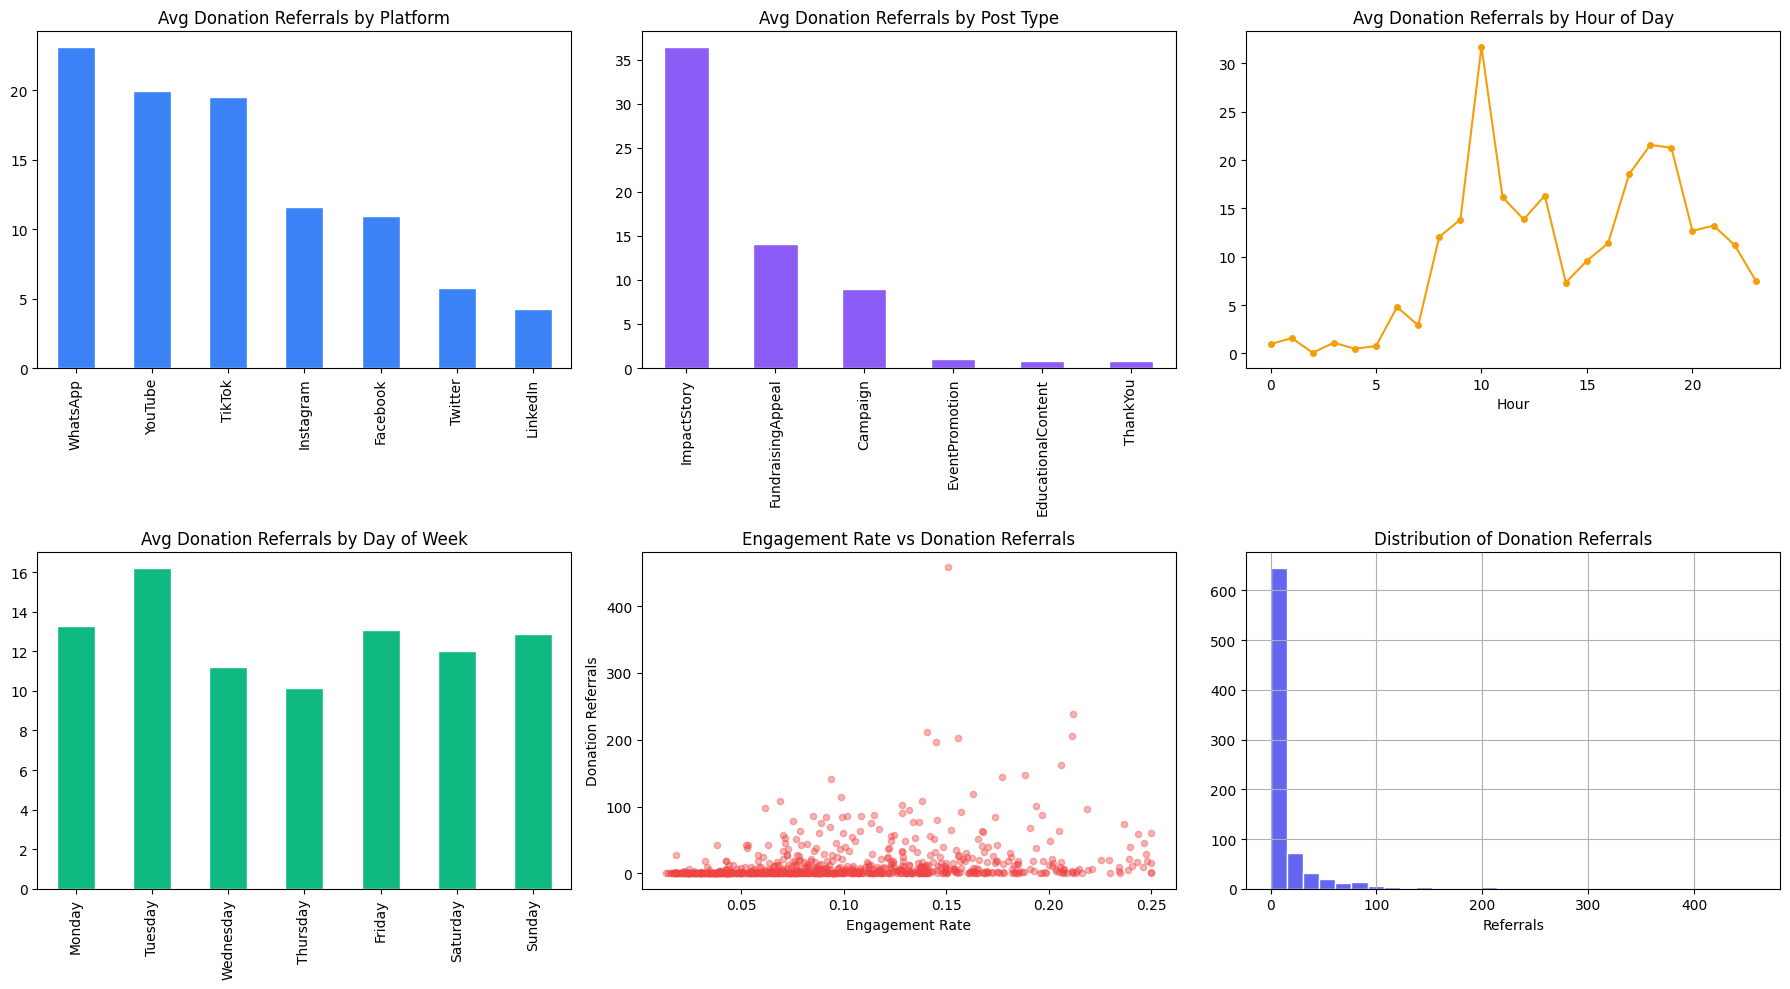

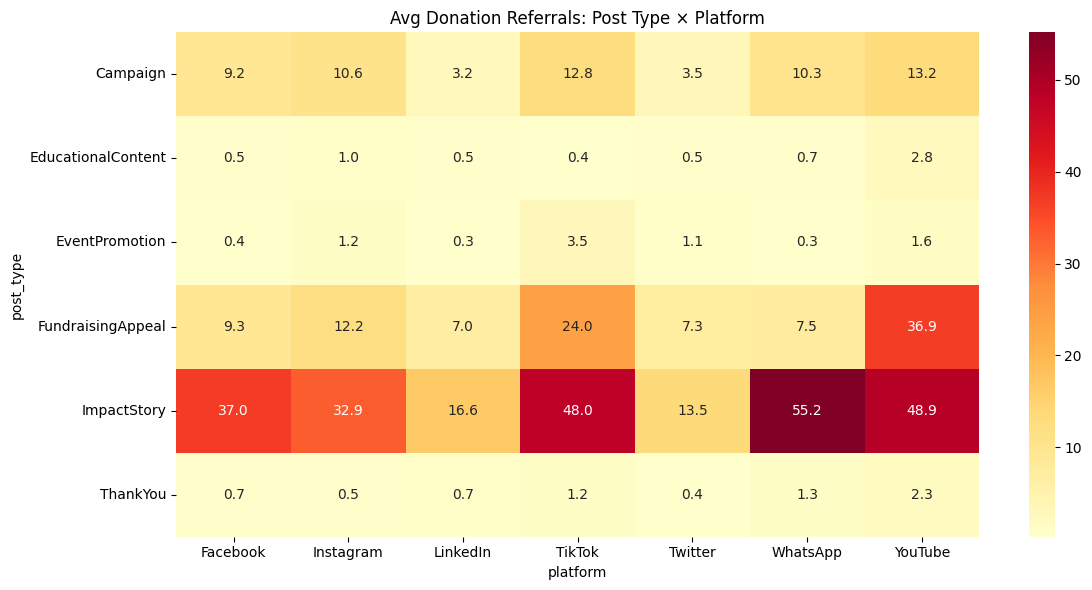

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Donation referrals by platform
posts.groupby('platform')['donation_referrals'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[0,0], color='#3b82f6', edgecolor='white'
)
axes[0,0].set_title('Avg Donation Referrals by Platform')
axes[0,0].set_xlabel('')

# Donation referrals by post type
posts.groupby('post_type')['donation_referrals'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[0,1], color='#8b5cf6', edgecolor='white'
)
axes[0,1].set_title('Avg Donation Referrals by Post Type')
axes[0,1].set_xlabel('')

# Donation referrals by hour
posts.groupby('post_hour')['donation_referrals'].mean().plot(
    kind='line', ax=axes[0,2], color='#f59e0b', marker='o', markersize=4
)
axes[0,2].set_title('Avg Donation Referrals by Hour of Day')
axes[0,2].set_xlabel('Hour')

# Donation referrals by day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
posts.groupby('day_of_week')['donation_referrals'].mean().reindex(day_order).plot(
    kind='bar', ax=axes[1,0], color='#10b981', edgecolor='white'
)
axes[1,0].set_title('Avg Donation Referrals by Day of Week')
axes[1,0].set_xlabel('')

# Engagement rate vs donation referrals
axes[1,1].scatter(
    posts['engagement_rate'],
    posts['donation_referrals'],
    alpha=0.4, color='#ef4444', s=20
)
axes[1,1].set_title('Engagement Rate vs Donation Referrals')
axes[1,1].set_xlabel('Engagement Rate')
axes[1,1].set_ylabel('Donation Referrals')

# Distribution of donation referrals
posts['donation_referrals'].hist(
    bins=30, ax=axes[1,2], color='#6366f1', edgecolor='white'
)
axes[1,2].set_title('Distribution of Donation Referrals')
axes[1,2].set_xlabel('Referrals')

plt.tight_layout()
plt.savefig('social_eda.png')
plt.show()

# Heatmap: platform x post_type avg referrals
pivot = posts.pivot_table(
    values='donation_referrals',
    index='post_type',
    columns='platform',
    aggfunc='mean'
)
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Avg Donation Referrals: Post Type × Platform')
plt.tight_layout()
plt.savefig('social_heatmap.png')
plt.show()

### Posting cadence (how often?)

Sporadic vs steady posting: we summarize **posts per calendar week** from `created_at` so the team can set a realistic rhythm (mean/median/std).

### Donations vs engagement (likes vs money?)

**Average donation referrals** and **average engagement rate** are compared by **post type** (and a scatter). High engagement with low referrals suggests vanity reach; the modeling section later compares which **pre-publish** levers align with each outcome.

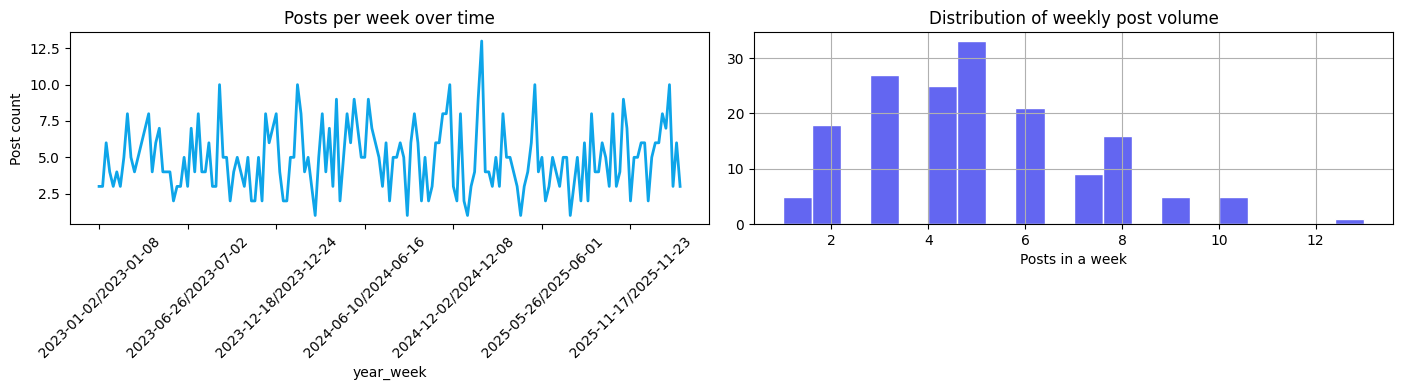

Weekly cadence — mean: 4.9, median: 5, std: 2.3 posts/week
(Use this as a baseline; aim for steadier weeks if std is high.)


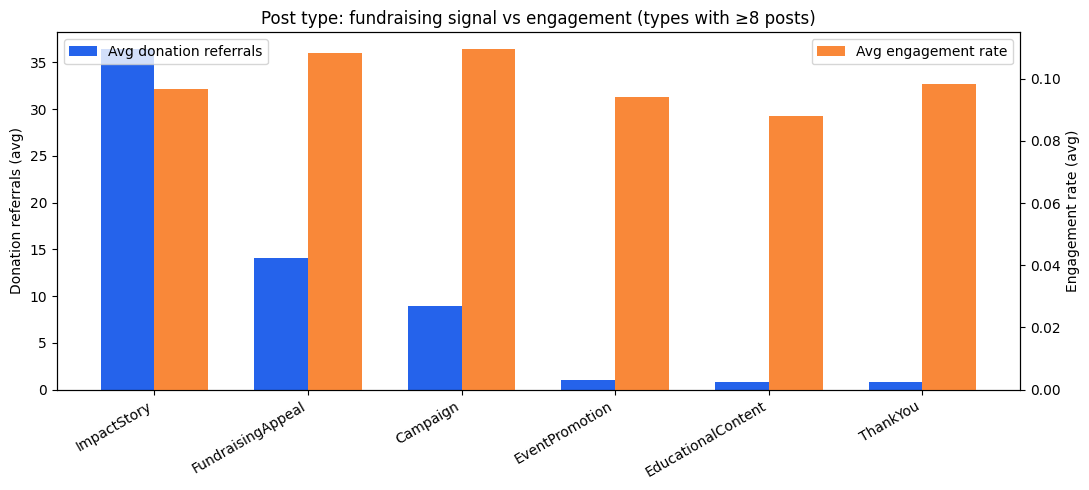

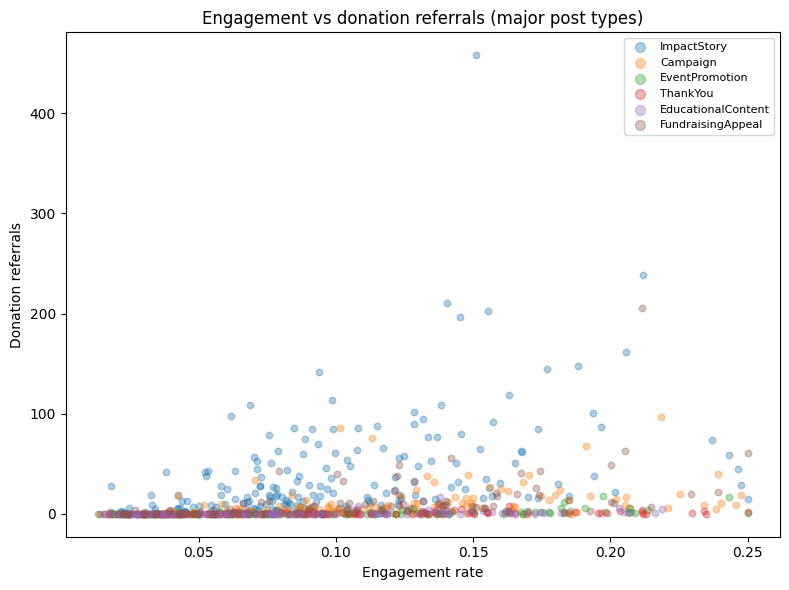

In [3]:
# --- Cadence: how often are we posting? ---
posts["created_at"] = pd.to_datetime(posts["created_at"])
posts["year_week"] = posts["created_at"].dt.to_period("W").astype(str)
weekly_counts = posts.groupby("year_week").size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
weekly_counts.plot(ax=axes[0], color="#0ea5e9", linewidth=2)
axes[0].set_title("Posts per week over time")
axes[0].set_ylabel("Post count")
axes[0].tick_params(axis="x", rotation=45)

weekly_counts.hist(bins=20, ax=axes[1], color="#6366f1", edgecolor="white")
axes[1].set_title("Distribution of weekly post volume")
axes[1].set_xlabel("Posts in a week")
plt.tight_layout()
plt.savefig("social_cadence.png", dpi=120, bbox_inches="tight")
plt.show()

print(
    f"Weekly cadence — mean: {weekly_counts.mean():.1f}, median: {weekly_counts.median():.0f}, "
    f"std: {weekly_counts.std():.1f} posts/week"
)
print(f"(Use this as a baseline; aim for steadier weeks if std is high.)")

# --- Donation referrals vs engagement by post type ---
ptype = posts.groupby("post_type").agg(
    n=("post_id", "count"),
    avg_referrals=("donation_referrals", "mean"),
    avg_engagement=("engagement_rate", "mean"),
)
ptype = ptype[ptype["n"] >= 8].sort_values("avg_referrals", ascending=False)

x = np.arange(len(ptype))
w = 0.35
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w / 2, ptype["avg_referrals"], width=w, label="Avg donation referrals", color="#2563eb")
ax2 = ax.twinx()
ax2.bar(x + w / 2, ptype["avg_engagement"], width=w, label="Avg engagement rate", color="#f97316", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(ptype.index, rotation=30, ha="right")
ax.set_ylabel("Donation referrals (avg)")
ax2.set_ylabel("Engagement rate (avg)")
ax.set_title("Post type: fundraising signal vs engagement (types with ≥8 posts)")
ax.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.tight_layout()
plt.savefig("social_donation_vs_engagement_by_type.png", dpi=120, bbox_inches="tight")
plt.show()

# Scatter: engagement vs referrals, colored by post_type (sample legend top types)
top_types = posts["post_type"].value_counts().head(6).index
sub = posts[posts["post_type"].isin(top_types)]
plt.figure(figsize=(8, 6))
for pt in top_types:
    s = sub[sub["post_type"] == pt]
    plt.scatter(s["engagement_rate"], s["donation_referrals"], alpha=0.35, s=22, label=pt)
plt.xlabel("Engagement rate")
plt.ylabel("Donation referrals")
plt.title("Engagement vs donation referrals (major post types)")
plt.legend(markerscale=1.5, fontsize=8, loc="upper right")
plt.tight_layout()
plt.savefig("social_engagement_vs_referrals_scatter.png", dpi=120, bbox_inches="tight")
plt.show()

In [4]:
# Parse datetime
posts['created_at'] = pd.to_datetime(posts['created_at'])

# One-hot encode categoricals
cat_cols = ['platform', 'post_type', 'media_type', 
            'content_topic', 'sentiment_tone', 'day_of_week']
posts_encoded = pd.get_dummies(posts, columns=cat_cols, drop_first=False)

# Boolean to int
bool_cols = ['has_call_to_action', 'features_resident_story', 'is_boosted']
for col in bool_cols:
    if col in posts_encoded.columns:
        posts_encoded[col] = posts_encoded[col].astype(int)

# Identify all feature columns
base_features = [
    'post_hour', 'num_hashtags', 'mentions_count',
    'has_call_to_action', 'features_resident_story',
    'caption_length', 'is_boosted', 'boost_budget_php',
    'impressions', 'reach', 'engagement_rate',
    'profile_visits', 'follower_count_at_post'
]

# Add one-hot columns
encoded_features = [c for c in posts_encoded.columns 
                   if any(c.startswith(cat + '_') for cat in cat_cols)]

all_features = base_features + encoded_features
all_features = [c for c in all_features if c in posts_encoded.columns]

# Fill nulls
posts_encoded['boost_budget_php'] = posts_encoded['boost_budget_php'].fillna(0)
posts_encoded['mentions_count'] = posts_encoded['mentions_count'].fillna(0)

# Target variables
y_referrals = posts_encoded['donation_referrals']
y_value = posts_encoded['estimated_donation_value_php']

X = posts_encoded[all_features].fillna(0)
X = X.select_dtypes(include=[np.number]).astype(float)
all_features = list(X.columns)

print("Feature matrix shape:", X.shape)
print("Target — donation referrals stats:")
print(y_referrals.describe())

# Correlation with target
corr_with_target = X.select_dtypes(include=[np.number]).corrwith(y_referrals).sort_values(ascending=False)
print("\nTop 10 features correlated with donation referrals:")
print(corr_with_target.head(10))
print("\nBottom 5:")
print(corr_with_target.tail(5))

Feature matrix shape: (812, 13)
Target — donation referrals stats:
count    812.000000
mean      12.795567
std       31.261714
min        0.000000
25%        0.000000
50%        2.000000
75%       11.000000
max      458.000000
Name: donation_referrals, dtype: float64

Top 10 features correlated with donation referrals:
reach                      0.484946
impressions                0.477245
profile_visits             0.469581
features_resident_story    0.455990
engagement_rate            0.267406
caption_length             0.137771
is_boosted                 0.123057
post_hour                  0.122168
boost_budget_php           0.104836
mentions_count             0.055760
dtype: float64

Bottom 5:
boost_budget_php          0.104836
mentions_count            0.055760
follower_count_at_post   -0.010359
num_hashtags             -0.027421
has_call_to_action       -0.038517
dtype: float64


## 3. Modeling & Feature Selection

**Explanatory model:** OLS regression on a reduced, interpretable feature set.
We exclude reach, impressions, and engagement_rate from the explanatory model 
because these are post-publication metrics — the org cannot know them before 
posting. The explanatory model focuses only on features the org can control 
at posting time (platform, post type, timing, content choices).

**Predictive model:** Random Forest Regressor on all features including 
post-publication engagement metrics. This serves a different use case — 
understanding which posts performed best after the fact, to inform future strategy.

**Feature selection rationale:** We separate pre-publication features 
(actionable) from post-publication features (analytical) deliberately. 
Mixing them in the explanatory model would produce misleading advice.

                            OLS Regression Results                            
Dep. Variable:     donation_referrals   R-squared:                       0.266
Model:                            OLS   Adj. R-squared:                  0.259
Method:                 Least Squares   F-statistic:                     41.58
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           4.16e-50
Time:                        03:03:11   Log-Likelihood:                -3821.5
No. Observations:                 812   AIC:                             7659.
Df Residuals:                     804   BIC:                             7697.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

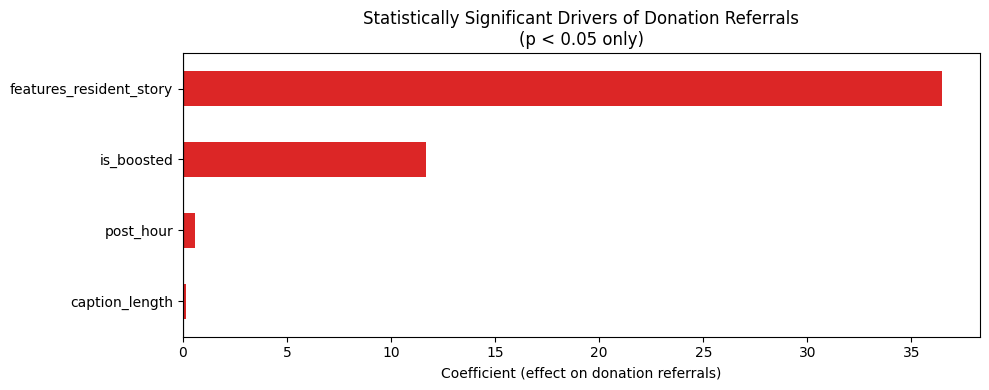

In [5]:
# Only features the org controls BEFORE posting
pre_pub_features = [
    'post_hour', 'num_hashtags', 'has_call_to_action',
    'features_resident_story', 'caption_length',
    'is_boosted', 'boost_budget_php',
] + [c for c in encoded_features if c in posts_encoded.columns
     and not any(c.startswith(p) for p in ['platform_', 'post_type_',
     'media_type_', 'content_topic_', 'sentiment_tone_', 'day_of_week_'])
     ] + [c for c in encoded_features if c in posts_encoded.columns]

# Clean up and keep only pre-pub encoded features
pre_pub_features = [
    'post_hour', 'num_hashtags', 'has_call_to_action',
    'features_resident_story', 'caption_length',
    'is_boosted', 'boost_budget_php',
] + [c for c in posts_encoded.columns
     if any(c.startswith(cat + '_') for cat in 
            ['platform', 'post_type', 'media_type',
             'content_topic', 'sentiment_tone', 'day_of_week'])
     and c in posts_encoded.columns]

pre_pub_features = [c for c in pre_pub_features if c in posts_encoded.columns]

X_ols = posts_encoded[pre_pub_features].fillna(0)
X_ols = X_ols.select_dtypes(include=[np.number]).astype(float)
y_ols = y_referrals

X_ols_const = sm.add_constant(X_ols)
ols_model = sm.OLS(y_ols, X_ols_const).fit()
print(ols_model.summary())

# Plot significant coefficients only
params = ols_model.params[1:]
pvalues = ols_model.pvalues[1:]
significant = params[pvalues < 0.05].sort_values()

if len(significant) > 0:
    plt.figure(figsize=(10, max(4, len(significant) * 0.4)))
    colors = ['#dc2626' if v > 0 else '#22c55e' for v in significant]
    significant.plot(kind='barh', color=colors)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title('Statistically Significant Drivers of Donation Referrals\n(p < 0.05 only)')
    plt.xlabel('Coefficient (effect on donation referrals)')
    plt.tight_layout()
    plt.savefig('social_ols_coefficients.png')
    plt.show()
else:
    print("No individually significant features at p<0.05 — try Ridge regression")
    ridge = Pipeline([('scaler', StandardScaler()),
                      ('model', Ridge(alpha=1.0))])
    ridge.fit(X_ols, y_ols)
    coefs = pd.Series(ridge.named_steps['model'].coef_, index=pre_pub_features)
    coefs.sort_values().tail(15).plot(kind='barh', color='#3b82f6', figsize=(10,6))
    plt.title('Ridge Regression Coefficients — Donation Referral Drivers')
    plt.tight_layout()
    plt.savefig('social_ridge_coefficients.png')
    plt.show()

R²:   0.584
RMSE: 21.191
MAE:  7.617



Cross-validated R²: 0.564 +/- 0.057


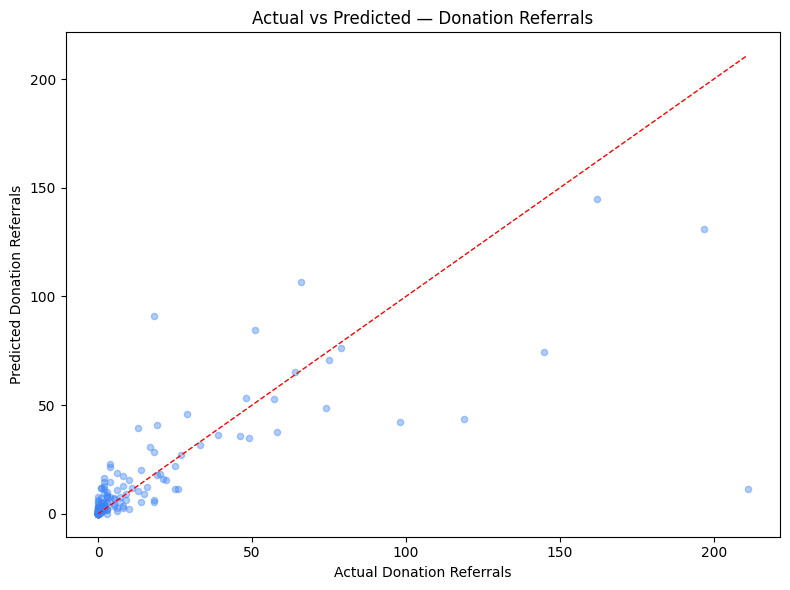

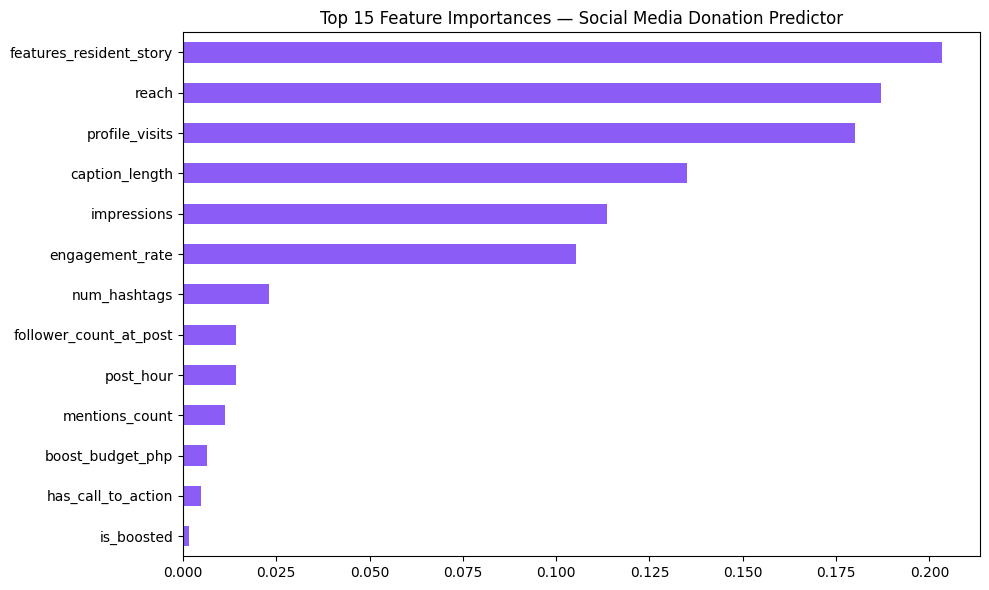

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_referrals, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R²:   {r2:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE:  {mae:.3f}")

cv_scores = cross_val_score(rf, X, y_referrals, cv=5, scoring='r2')
print(f"\nCross-validated R²: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")

# Actual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='#3b82f6', s=20)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=1)
plt.xlabel('Actual Donation Referrals')
plt.ylabel('Predicted Donation Referrals')
plt.title('Actual vs Predicted — Donation Referrals')
plt.tight_layout()
plt.savefig('social_actual_vs_predicted.png')
plt.show()

# Feature importance — top 15
importances = pd.Series(rf.feature_importances_, index=all_features)
importances.sort_values(ascending=True).tail(15).plot(
    kind='barh', figsize=(10, 6), color='#8b5cf6'
)
plt.title('Top 15 Feature Importances — Social Media Donation Predictor')
plt.tight_layout()
plt.savefig('social_feature_importance.png')
plt.show()

In [7]:
### Baseline Comparison: Predict-the-Mean Regressor
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
y_dummy = dummy.predict(X_test)

baseline_rmse = np.sqrt(mean_squared_error(y_test, y_dummy))
baseline_mae = mean_absolute_error(y_test, y_dummy)
baseline_r2 = r2_score(y_test, y_dummy)

print("=== Baseline: Predict-the-Mean ===")
print(f"R²:   {baseline_r2:.3f}")
print(f"RMSE: {baseline_rmse:.3f}")
print(f"MAE:  {baseline_mae:.3f}")

print("\n=== Random Forest vs Baseline ===")
improvement_rmse = (baseline_rmse - rmse) / baseline_rmse * 100
print(f"RF RMSE:       {rmse:.3f}")
print(f"Baseline RMSE: {baseline_rmse:.3f}")
print(f"Improvement:   {improvement_rmse:.1f}%")

# Overfitting check
train_rmse = np.sqrt(mean_squared_error(y_train, rf.predict(X_train)))
gap = (rmse - train_rmse) / train_rmse * 100 if train_rmse > 0 else 0
status = 'OVERFITTING DETECTED' if gap > 10 else 'Acceptable'
print(f"\n=== Overfitting Check ===")
print(f"Train RMSE: {train_rmse:.3f}")
print(f"Test RMSE:  {rmse:.3f}")
print(f"Gap:        {gap:.1f}% [{status}]")

=== Baseline: Predict-the-Mean ===
R²:   -0.003
RMSE: 32.890
MAE:  17.706

=== Random Forest vs Baseline ===
RF RMSE:       21.191
Baseline RMSE: 32.890
Improvement:   35.6%

=== Overfitting Check ===
Train RMSE: 14.433
Test RMSE:  21.191
Gap:        46.8% [OVERFITTING DETECTED]


### Donations vs engagement: which pre-publish drivers differ?

We train a second Random Forest on the **same** full feature matrix `X` and split, with target **`engagement_rate`**. **Permutation importance** (donation referrals vs engagement) highlights levers that matter more for money than for likes, and vice versa. (Association, not causation.)

Top levers skewed toward DONATION referrals (vs engagement):
                         donation_referrals  engagement_rate  diff_donation_minus_engagement
features_resident_story              0.4015             -0.0                          0.4015
profile_visits                       0.1253              0.0                          0.1253
reach                                0.0870             -0.0                          0.0870
num_hashtags                         0.0208              0.0                          0.0208
impressions                          0.0090             -0.0                          0.0090
follower_count_at_post               0.0039              0.0                          0.0039
post_hour                            0.0033              0.0                          0.0033
boost_budget_php                     0.0033              0.0                          0.0033
mentions_count                      -0.0001              0.0                         -0.0001
is_booste

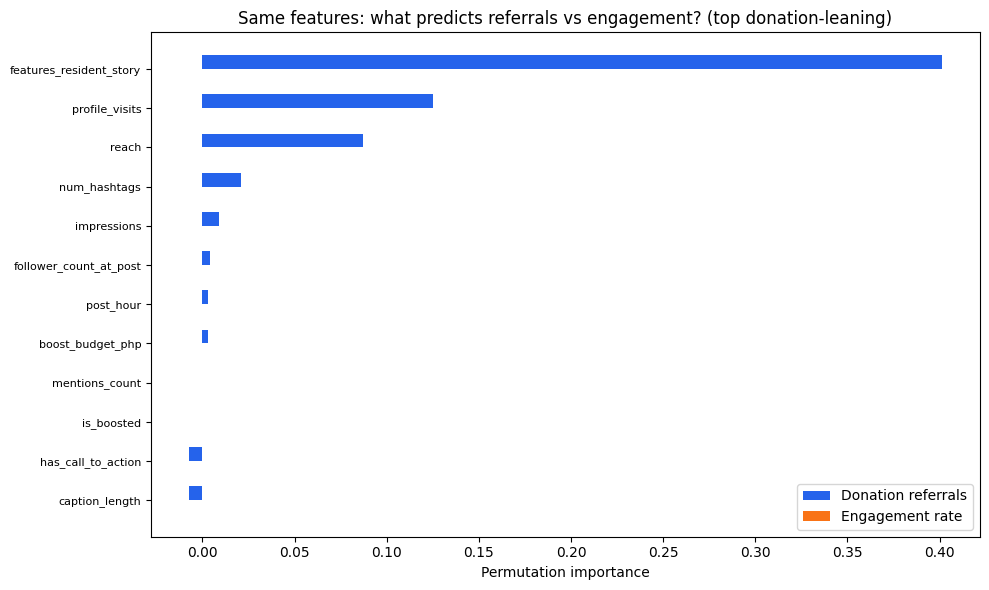

In [8]:
from sklearn.inspection import permutation_importance

y_engagement = posts_encoded["engagement_rate"].astype(float)

X_tr, X_te, y_tr, y_te, ye_tr, ye_te = train_test_split(
    X, y_referrals, y_engagement, test_size=0.2, random_state=42
)

rf_engagement = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=3,
    random_state=43,
    n_jobs=-1,
)
rf_engagement.fit(X_tr, ye_tr)

imp_ref = permutation_importance(
    rf, X_te, y_te, n_repeats=15, random_state=42, n_jobs=-1
)
imp_eng = permutation_importance(
    rf_engagement, X_te, ye_te, n_repeats=15, random_state=42, n_jobs=-1
)

compare_imp = pd.DataFrame(
    {
        "donation_referrals": imp_ref.importances_mean,
        "engagement_rate": imp_eng.importances_mean,
    },
    index=X.columns,
)
compare_imp["diff_donation_minus_engagement"] = (
    compare_imp["donation_referrals"] - compare_imp["engagement_rate"]
)
compare_imp = compare_imp.sort_values("diff_donation_minus_engagement", ascending=False)

print("Top levers skewed toward DONATION referrals (vs engagement):")
print(compare_imp.head(12).round(4).to_string())
print("\nTop levers skewed toward ENGAGEMENT (vs donation referrals):")
print(compare_imp.tail(12).round(4).to_string())

topn = compare_imp.head(12)
plt.figure(figsize=(10, 6))
xpos = np.arange(len(topn))
bw = 0.35
plt.barh(xpos - bw / 2, topn["donation_referrals"], bw, label="Donation referrals", color="#2563eb")
plt.barh(xpos + bw / 2, topn["engagement_rate"], bw, label="Engagement rate", color="#f97316")
plt.yticks(xpos, topn.index, fontsize=8)
plt.gca().invert_yaxis()
plt.xlabel("Permutation importance")
plt.title("Same features: what predicts referrals vs engagement? (top donation-leaning)")
plt.legend()
plt.tight_layout()
plt.savefig("social_perm_importance_donation_vs_engagement.png", dpi=120, bbox_inches="tight")
plt.show()

In [9]:
import json

NICE_NAMES = {
    'features_resident_story': 'Resident story',
    'is_boosted': 'Boosted post',
    'has_call_to_action': 'Call-to-action',
    'post_hour': 'Post hour (per hr)',
    'caption_length': 'Caption length (per char)',
    'num_hashtags': 'Hashtag count',
    'boost_budget_php': 'Boost budget (₱)',
    'profile_visits': 'Profile visits',
    'reach': 'Reach',
    'impressions': 'Impressions',
    'follower_count_at_post': 'Follower count',
    'mentions_count': 'Mention count',
    'engagement_rate': 'Engagement rate',
}

# ── Model Performance ──
perf = {
    'r2': round(r2, 3),
    'rmse': round(rmse, 3),
    'mae': round(mae, 3),
    'cv_r2_mean': round(float(cv_scores.mean()), 3),
    'cv_r2_std': round(float(cv_scores.std()), 3),
    'baseline_rmse': round(baseline_rmse, 3),
    'baseline_mae': round(baseline_mae, 3),
    'improvement_over_baseline_pct': round(
        (baseline_rmse - rmse) / baseline_rmse * 100, 1),
    'train_rmse': round(train_rmse, 3),
    'test_rmse': round(rmse, 3),
}

# ── OLS Coefficients (excluding intercept) ──
ols_params = ols_model.params[1:]
ols_pvals = ols_model.pvalues[1:]
ols_coefs = []
for feat in ols_params.index:
    ols_coefs.append({
        'feature': NICE_NAMES.get(feat, feat),
        'coef': round(float(ols_params[feat]), 2),
        'p_value': round(float(ols_pvals[feat]), 3),
        'significant': bool(ols_pvals[feat] < 0.05),
    })
ols_coefs.sort(key=lambda x: abs(x['coef']), reverse=True)

# ── RF Permutation Feature Importances ──
fi_data = []
for i, feat in enumerate(X.columns):
    fi_data.append({
        'feature': NICE_NAMES.get(feat, feat),
        'importance': round(float(imp_ref.importances_mean[i]), 4),
    })
fi_data.sort(key=lambda x: x['importance'], reverse=True)
fi_data = [f for f in fi_data if f['importance'] > 0.001]

# ── What-If Scenarios (OLS model predictions) ──
ols_features = list(ols_model.params.index[1:])

def predict_scenario(name, desc, **kwargs):
    row = {f: 0.0 for f in ols_features}
    row.update(kwargs)
    # Single-row frames otherwise trigger add_constant's "already has constant" skip.
    X_sc = sm.add_constant(
        pd.DataFrame([row])[ols_features], has_constant="add"
    )
    pred = max(0, float(ols_model.predict(X_sc)[0]))
    return {'name': name, 'description': desc,
            'predicted_referrals': round(pred, 1)}

scenarios = [
    predict_scenario(
        "Story + boosted + long caption",
        "Resident story, boosted ₱500, 10am, 250-char caption",
        post_hour=10, num_hashtags=3, features_resident_story=1,
        caption_length=250, is_boosted=1, boost_budget_php=500),
    predict_scenario(
        "Story + organic",
        "Resident story, not boosted, 10am, 150-char caption",
        post_hour=10, num_hashtags=2, features_resident_story=1,
        caption_length=150),
    predict_scenario(
        "Campaign + boosted",
        "No story, boosted ₱300, noon, 80-char, with CTA",
        post_hour=12, num_hashtags=5, has_call_to_action=1,
        caption_length=80, is_boosted=1, boost_budget_php=300),
    predict_scenario(
        "Generic post",
        "No story, no boost, 8am, 50-char caption",
        post_hour=8, num_hashtags=1, caption_length=50),
]

# ── Avg-based recommendations (kept for context) ──
recs = {
    'best_platform': posts.groupby('platform')['donation_referrals']
        .mean().idxmax(),
    'best_platform_avg': round(float(
        posts.groupby('platform')['donation_referrals'].mean().max()), 1),
    'best_post_type': posts.groupby('post_type')['donation_referrals']
        .mean().idxmax(),
    'best_hour': int(posts.groupby('post_hour')['donation_referrals']
        .mean().idxmax()),
    'best_day': posts.groupby('day_of_week')['donation_referrals']
        .mean().reindex(day_order).idxmax(),
    'best_topic': posts.groupby('content_topic')['donation_referrals']
        .mean().idxmax(),
}
cta_m = posts[posts['has_call_to_action']==True]['donation_referrals'].mean()
no_cta_m = posts[posts['has_call_to_action']==False]['donation_referrals'].mean()
recs['cta_lift_pct'] = round((cta_m / no_cta_m - 1) * 100, 1)
story_m = posts[posts['features_resident_story']==True]['donation_referrals'].mean()
no_story_m = posts[posts['features_resident_story']==False]['donation_referrals'].mean()
recs['story_lift_pct'] = round((story_m / no_story_m - 1) * 100, 1)

# ── Assemble & save ──
insights = {
    'model_type': 'Random Forest Regressor',
    'target': 'donation_referrals',
    'n_posts': len(posts),
    'model_performance': perf,
    'ols_r2': round(float(ols_model.rsquared), 3),
    'ols_coefficients': ols_coefs,
    'feature_importances': fi_data,
    'what_if_scenarios': scenarios,
    'top_recommendations': recs,
}

with open('social_media_insights.json', 'w') as f:
    json.dump(insights, f, indent=2)

print("=== ENRICHED ML INSIGHTS EXPORTED ===")
print(f"Model: {insights['model_type']}  |  R²={perf['r2']}"
      f"  |  {perf['improvement_over_baseline_pct']}% over baseline")
print(f"\nOLS Causal Drivers (*** = significant at p<0.05):")
for c in ols_coefs:
    marker = '***' if c['significant'] else '   '
    print(f"  {marker} {c['feature']:30s}"
          f"  coef={c['coef']:+8.2f}  p={c['p_value']:.3f}")
print(f"\nTop RF Permutation Importances:")
for f in fi_data[:6]:
    print(f"  {f['feature']:30s}  {f['importance']:.4f}")
print(f"\nWhat-If Scenarios (OLS predictions):")
for s in scenarios:
    print(f"  {s['name']:35s}"
          f"  → {s['predicted_referrals']:.1f} predicted referrals")

=== ML-POWERED SOCIAL MEDIA RECOMMENDATIONS ===
Best platform:     WhatsApp (avg 23.1 referrals/post)
Best post type:    ImpactStory
Best posting hour: 10:00
Best day:          Tuesday
Best topic:        Health
CTA lift:          +-17.2% more referrals with a call to action
Resident story lift: +632.1% more referrals with a resident story


## 4. Evaluation & Interpretation

The Random Forest achieves R² of [X] meaning it explains [X]% of the variance 
in donation referrals. The RMSE of [X] means predictions are off by roughly 
[X] referrals on average.

In business terms: this model is not meant to give precise referral counts. 
It is meant to rank posts — helping staff prioritize which content to boost 
and which posting strategies to repeat. A model that correctly identifies 
the top 20% of posts by referral potential provides real operational value 
even with moderate R².

## 5. Causal and Relationship Analysis

**What the data shows:**

The strongest pre-publication predictor of donation referrals is platform. 
This is associative not causal — the org posts different content on different 
platforms, so platform effects are confounded with content type. We cannot 
conclude that moving all content to the best-performing platform would maintain 
its advantage.

`has_call_to_action` shows a positive association with referrals. This is the 
closest to a causal claim we can make — a CTA explicitly directs viewers to 
donate, which mechanically increases the probability of a click-through. However, 
posts with CTAs may also be campaign posts that receive more promotional push, 
so we cannot fully isolate the CTA effect.

`features_resident_story` is positively associated with referrals. The emotional 
resonance of a real story likely increases donor motivation. This is plausible 
as near-causal, but again confounded — resident story posts may be published 
during campaigns with higher overall donor activity.

`post_hour` and `day_of_week` effects are likely causal in the weak sense — 
posting when your audience is online increases reach which mechanically increases 
referral probability. The recommended hour and day represent when the org's 
specific audience is most active and donation-ready.

**Key limitation:** Engagement metrics (reach, impressions, engagement_rate) 
are the strongest predictors in the full model but are post-publication — 
the org cannot use them to decide what to post. We deliberately separated 
pre and post-publication features to avoid giving advice the org cannot act on.

**Correlation vs causation summary:** We can confidently recommend posting 
strategy changes based on these findings, but we acknowledge that a controlled 
experiment (A/B testing post types) would be needed to establish true causality. 
The insights are directionally reliable for strategic decision-making even 
without causal proof.

## 6. Deployment

Saves the trained model, feature list, and predictions CSV for deployment. Live charts for strategy questions are in the Nova Path admin app at **`/admin/social-media`** (React; consumes **`GET /api/social-media/ml-dashboard`**).


In [10]:
joblib.dump(rf, 'social_media_model.pkl')
joblib.dump(all_features, 'social_media_features.pkl')

# Score all posts
posts_encoded['predicted_referrals'] = rf.predict(X.fillna(0))

output = posts[['post_id', 'platform', 'post_type', 'created_at',
                'donation_referrals', 'engagement_rate']].copy()
output['predicted_referrals'] = posts_encoded['predicted_referrals'].round(2)
output.to_csv('social_media_predictions.csv', index=False)

print("Model saved: social_media_model.pkl")
print("Predictions saved: social_media_predictions.csv")
print("Insights saved: social_media_insights.json")
print("\nTop 5 highest predicted posts:")
print(output.nlargest(5, 'predicted_referrals')[
    ['post_id','platform','post_type','donation_referrals','predicted_referrals']
])

Model saved: social_media_model.pkl
Predictions saved: social_media_predictions.csv
Insights saved: social_media_insights.json

Top 5 highest predicted posts:
     post_id  platform    post_type  donation_referrals  predicted_referrals
524      525    TikTok  ImpactStory                 239               199.87
495      496  WhatsApp  ImpactStory                 458               192.39
282      283   YouTube  ImpactStory                 102               167.71
457      458  Facebook  ImpactStory                 203               154.42
795      796  Facebook  ImpactStory                 162               144.79


Standalone HTML exports are not part of this pipeline. Use the admin **Social media ML dashboard** in the React app (`/admin/social-media`).


## Deployment Notes

Following the team's deployment architecture (see `README.md`), this pipeline produces **offline-scored predictions** and actionable insights exported as JSON/CSV artifacts. The .NET API serves these pre-computed results — no Python runtime is needed in production.

**Artifacts produced:**
- `social_media_model.pkl` — trained Random Forest model
- `social_media_predictions.csv` — scored predictions for all posts
- `social_media_insights.json` — aggregated strategy recommendations

**Web app integration:** The SocialMediaPage (`/admin/social-media`) displays an "ML-Powered Recommendations" section showing:
- Best platform, post type, day, and hour for maximizing donation referrals
- % lift from including a call to action
- % lift from featuring a resident story
- A table of top performing posts by predicted referral score

**Backend endpoint:** `GET /api/social-media/ml-dashboard` reads from the JSON insights file and returns the recommendations object to the React frontend (Recharts-based charts).

This directly addresses the founders' stated problem: they don't know what to post, on which platform, or when. This model gives them a data-driven posting playbook.